[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/07_data_vis/07_5_Third_Variable_Faceting.ipynb)

# 07.5: Adding a Third Variable and Faceting

Every chart so far has shown at most two variables. Real data has more dimensions than that. This notebook introduces two strategies for showing a third variable: encoding it with a visual channel (color, size, or line style) and splitting the chart into a grid of small panels called **facets**.

These strategies also unlock a new family of seaborn functions: the figure-level functions (`sns.relplot`, `sns.displot`, `sns.catplot`) that can produce multi-panel layouts in a single call.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

df = sns.load_dataset("titanic")
df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare"]].copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


## Visual channels: color, size, and style

You have already used `hue=` to encode a third variable as color. Seaborn also supports `size=` (marker size) and `style=` (marker shape or line dash pattern). Together, these are called **visual channels** or **aesthetic mappings**: each one maps a column of data to a visible property of the marks on the chart.

Here is a scatter plot using all three at once.

Text(0, 0.5, 'Fare')

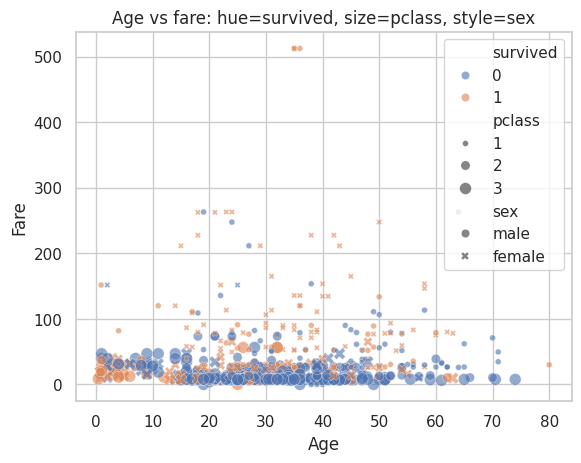

In [2]:
ax = sns.scatterplot(
    data=df.dropna(subset=["age"]),
    x="age", y="fare",
    hue="survived",
    size="pclass",
    style="sex",
    alpha=0.6
)
ax.set_title("Age vs fare: hue=survived, size=pclass, style=sex")
ax.set_xlabel("Age")
ax.set_ylabel("Fare")

That chart is hard to read. Color, size, and shape are competing for attention, and the legend alone takes up a third of the space. This is not a problem with seaborn; it is a problem with trying to encode four variables in a single panel. The human eye can comfortably track two or three visual properties at once. Beyond that, the chart becomes noise.

The general rule: use `hue=` freely, add `style=` when accessibility requires it (as a backup for color), and reach for `size=` only when the size difference is large and clearly meaningful. When you need to show more than two or three variables, faceting is usually cleaner.

## Faceting: one panel per category

**Faceting** (also called **small multiples**) breaks a chart into a grid of panels, one per category value. Each panel shows the same chart type on the same axis scale, which makes comparing across panels easy. The chart does not get more complex; it just gets wider.

Seaborn's figure-level functions handle faceting directly. Instead of calling `sns.histplot()` and passing an existing `ax`, you call `sns.displot()` and tell it which column to use for `col=` or `row=`.

## `sns.relplot()`: scatter and line plots across panels

`sns.relplot()` is the figure-level counterpart to `sns.scatterplot()` and `sns.lineplot()`. The `kind=` argument switches between the two. The `col=` argument creates one panel per unique value of the specified column.

Text(0.5, 1.02, 'Age vs fare by passenger class')

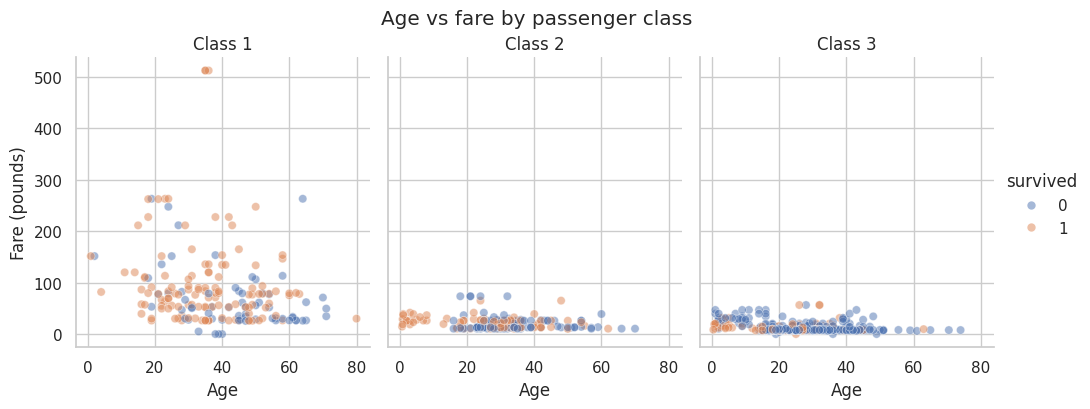

In [3]:
g = sns.relplot(
    data=df.dropna(subset=["age"]),
    x="age", y="fare",
    hue="survived",
    col="pclass",
    col_order=[1, 2, 3],
    kind="scatter",
    alpha=0.5,
    height=4, aspect=0.85
)
g.set_axis_labels("Age", "Fare (pounds)")
g.set_titles("Class {col_name}")
g.figure.suptitle("Age vs fare by passenger class", y=1.02)

Now each panel shows one class. The three panels share the same x and y scales, so you can directly compare: first-class fares span a much wider range (up to 512 pounds), while third-class fares are nearly all below 50 pounds. Within each panel, survivors (orange) still concentrate at higher fares, but the pattern is much clearer than in the single crowded chart.

Notice that `relplot()` returns a `FacetGrid` object (`g`), not a single `Axes`. You call `g.set_axis_labels()`, `g.set_titles()`, and `g.figure.suptitle()` on it, not `ax.set_*()` methods.

Text(0.5, 1.02, 'Survival rate by age, sex, and class')

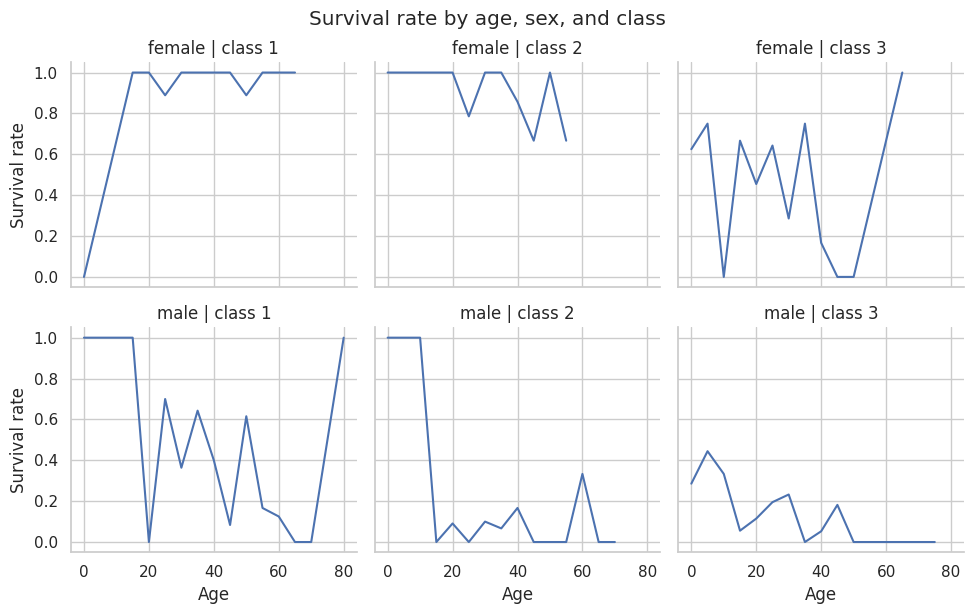

In [4]:
df_line = df.dropna(subset=["age"]).copy()
df_line["age_r"] = (df_line["age"] / 5).round() * 5

g = sns.relplot(
    data=df_line,
    x="age_r", y="survived",
    col="pclass", row="sex",
    col_order=[1, 2, 3],
    row_order=["female", "male"],
    kind="line",
    errorbar=None,
    height=3, aspect=1.1
)
g.set_axis_labels("Age", "Survival rate")
g.set_titles("{row_name} | class {col_name}")
g.figure.suptitle("Survival rate by age, sex, and class", y=1.02)

This 2x3 grid tells the full story in one view. Female survival rates (top row) are high across all three classes and ages, though they drop in third class. Male survival rates (bottom row) are low everywhere. Reading across each row, you can see how class modifies the pattern within each sex. Reading down each column, you can see the gender gap within each class. No single chart could show all of this at once without becoming unreadable.

## `sns.displot()`: distribution charts across panels

`sns.displot()` is the figure-level counterpart to `sns.histplot()` and `sns.kdeplot()`. The `kind=` argument switches between `"hist"`, `"kde"`, and `"ecdf"`.

Text(0.5, 1.02, 'Age distribution by survival and class')

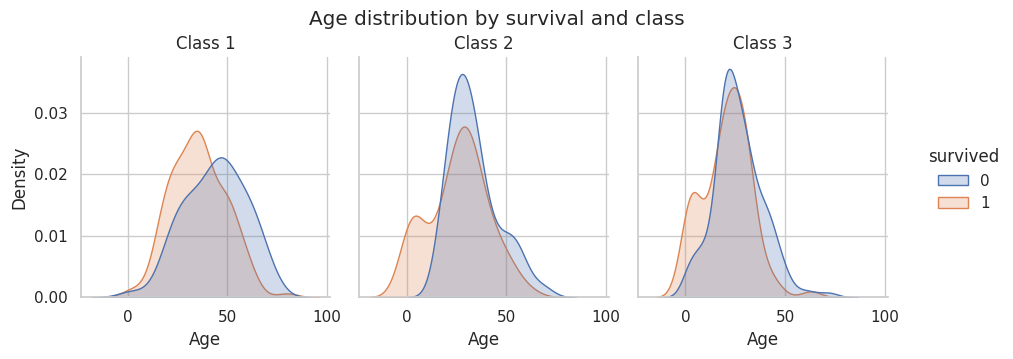

In [5]:
g = sns.displot(
    data=df,
    x="age",
    hue="survived",
    col="pclass",
    col_order=[1, 2, 3],
    kind="kde",
    fill=True,
    common_norm=False,
    height=3.5, aspect=0.9
)
g.set_axis_labels("Age", "Density")
g.set_titles("Class {col_name}")
g.figure.suptitle("Age distribution by survival and class", y=1.02)

In first class, the survivor and non-survivor age distributions are fairly similar, and both peak in the 30s and 40s. In third class, there is a small bump of young children in the survivor group that is absent in the non-survivor group, consistent with children being prioritized in the evacuation. The picture is nuanced: age alone did not determine survival, but it interacted with class in ways that are visible only when the two variables are shown together.

## `sns.catplot()`: categorical charts across panels

`sns.catplot()` is the figure-level counterpart to `sns.barplot()`, `sns.boxplot()`, `sns.violinplot()`, and `sns.countplot()`. The `kind=` argument switches between them.

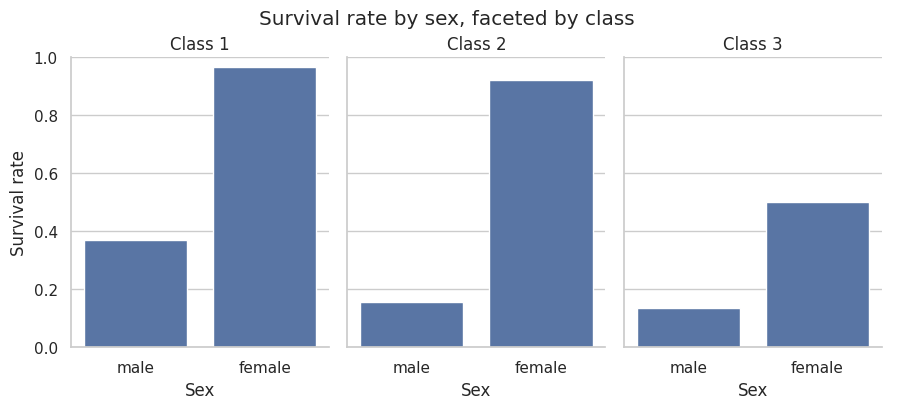

In [6]:
g = sns.catplot(
    data=df,
    x="sex", y="survived",
    col="pclass",
    col_order=[1, 2, 3],
    kind="bar",
    errorbar=None,
    height=4, aspect=0.75
)
g.set_axis_labels("Sex", "Survival rate")
g.set_titles("Class {col_name}")
g.figure.suptitle("Survival rate by sex, faceted by class", y=1.02)
for ax in g.axes.flat:
    ax.set_ylim(0, 1)

This single call replaces a complex groupby-and-plot workflow. Each panel is one class; each bar is one sex. The gender gap is visible in all three classes, but it is narrowest in third class (female survival at 50% vs male at 14%) and widest in first class (nearly 97% vs 37%).

Text(0.5, 1.02, 'Fare distribution by survival and class')

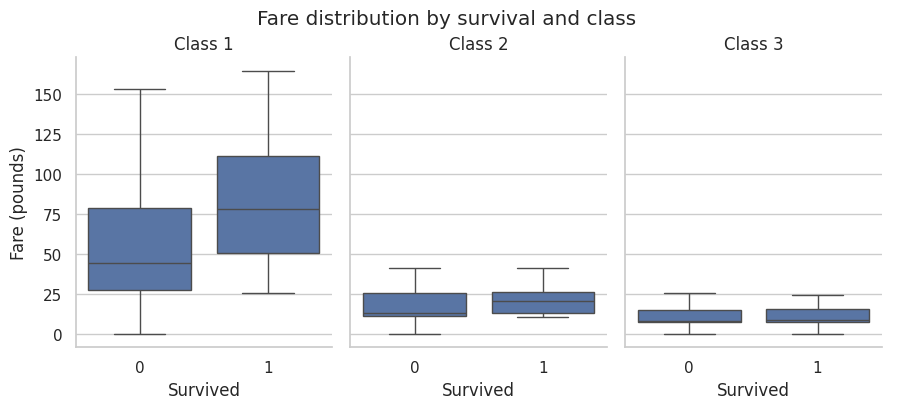

In [7]:
g = sns.catplot(
    data=df,
    x="survived", y="fare",
    col="pclass",
    col_order=[1, 2, 3],
    kind="box",
    showfliers=False,
    height=4, aspect=0.75
)
g.set_axis_labels("Survived", "Fare (pounds)")
g.set_titles("Class {col_name}")
g.figure.suptitle("Fare distribution by survival and class", y=1.02)

Within first class, survivors paid slightly higher median fares than non-survivors, but the ranges overlap substantially. Within third class, fares were low for both groups and barely distinguishable. Fare was not destiny; it was a correlate of class, and class was the more fundamental variable.

## Controlling panel size and layout

Figure-level functions do not accept `figsize=`. Instead they accept `height=` (the height of each panel in inches) and `aspect=` (the width-to-height ratio of each panel). The total figure size is determined automatically from these two values and the number of panels.

When you have many categories and only want one row of panels, `col_wrap=` limits the number of columns and wraps extra panels to a new row.

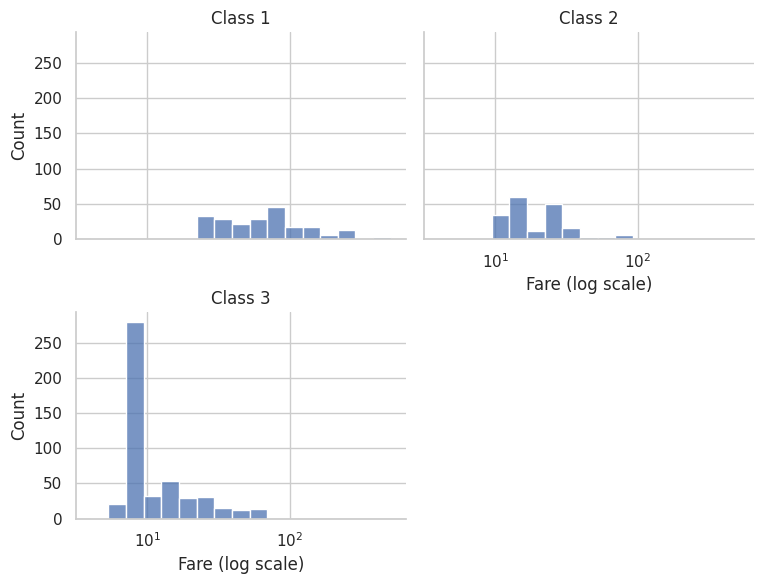

In [8]:
# Suppose we had many classes to compare — col_wrap keeps it tidy
g = sns.displot(
    data=df,
    x="fare",
    col="pclass",
    col_order=[1, 2, 3],
    col_wrap=2,
    log_scale=True,
    height=3, aspect=1.3
)
g.set_axis_labels("Fare (log scale)", "Count")
g.set_titles("Class {col_name}")

With `col_wrap=2`, the three panels wrap after the second column, producing a 2x2 grid with the third panel in the lower-left. This is useful when you have more categories than comfortably fit in one row.

## What's next

You now have the full toolkit for showing relationships across multiple variables. In 07.6 we ask a different question: instead of looking at one pair of variables at a time, how do we visualize all the pairwise relationships in a dataset at once? That leads to heatmaps and pair plots.